In [64]:
from sandbox.plt_dict import matplotlib_update
matplotlib_update()

In [65]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [66]:
def load_results_csvs(folder_path):
    """
    Reads all CSV files named results_{d}.csv (d = 1 or 2 digits)
    from the given folder and returns a dict of DataFrames.

    Returns:
        dict[int, pd.DataFrame]: {d: dataframe}
    """
    pattern = re.compile(r"^results_(\d{1,2})\.csv$")
    data = {}

    for filename in os.listdir(folder_path):
        match = pattern.match(filename)
        if match:
            d = int(match.group(1))
            file_path = os.path.join(folder_path, filename)
            df = pd.read_csv(file_path)
            data[d] = df

    return data

In [67]:
results = load_results_csvs("./sandbox/jordan8_results")

In [68]:
results[28].describe()

,true_class,pred_class,kl_loss,E_norm,S_cond,rad
count,280000.000000,280000.000000,2.800000e+05,280000.000000,280000.000000,280000.000000
mean,13.500000,13.492636,4.340416e-02,0.012176,248.813229,0.405717
std,8.077762,8.064180,1.825223e-01,0.031709,504.914835,0.263993
min,0.000000,0.000000,4.114084e-07,0.000000,12.724568,0.000000
25%,6.750000,7.000000,3.930535e-03,0.000002,56.747090,0.174504
50%,13.500000,13.000000,1.008097e-02,0.000089,98.776558,0.431308
75%,20.250000,21.000000,2.435001e-02,0.003991,208.712057,0.608831
max,27.000000,27.000000,1.418041e+01,0.214415,5599.826951,1.000000


In [69]:

def _assign_bins(series, bins):
    """
    Assign values to bins. Returns a categorical Series.
    """
    # Convert custom bin format into edges
    edges = [-np.inf]
    labels = []

    for b in bins:
        if isinstance(b, tuple):
            low, high = b
        else:
            # single value like (0)
            low, high = b, b

        edges.append(high)
        labels.append(f"{low:g}-{high:g}")

    edges[-1] = np.inf  # last bin open-ended

    return pd.cut(series, bins=edges, labels=labels, include_lowest=True)


def compute_metrics_by_E(
    results_dict,
    bins=None,
    k=0  # for accuracy@±k
):
    """
    Computes:
      - avg KL loss
      - accuracy
      - accuracy@±k

    grouped by dimension d and E_norm bins.

    Returns:
        metrics_df: pd.DataFrame (multi-metric)
        counts_df: pd.DataFrame (#samples per bin)
    """

    if bins is None:
        bins = [
            0,
            (1e-8, 1e-7),
            (1e-7, 1e-6),
            (1e-6, 1e-5),
            (1e-5, 1e-4),
            (1e-4, 1e-3),
            (1e-3, 1e-2),
            (1e-2, 1e-1),
        ]

    metrics_rows = []
    counts_rows = []

    for d, df in results_dict.items():
        df = df.copy()

        # Assign bins
        df["E_bin"] = _assign_bins(df["E_norm"], bins)

        # Metrics
        df["correct"] = df["true_class"] == df["pred_class"]
        df["correct_k"] = (df["true_class"] - df["pred_class"]).abs() <= k

        grouped = df.groupby("E_bin")

        avg_kl = grouped["kl_loss"].mean()
        acc = grouped["correct"].mean()
        acc_k = grouped["correct_k"].mean()
        counts = grouped.size()

        # Combine metrics
        metrics = pd.concat(
            {
                "avg_kl": avg_kl,
                "accuracy": acc,
                f"accuracy@±{k}": acc_k,
            },
            axis=1,
        )

        metrics["d"] = d
        counts = counts.to_frame(name="count")
        counts["d"] = d

        metrics_rows.append(metrics.reset_index())
        counts_rows.append(counts.reset_index())

    # Merge all
    metrics_df = pd.concat(metrics_rows)
    counts_df = pd.concat(counts_rows)

    # Pivot into final table form
    metrics_df = metrics_df.pivot(index="d", columns="E_bin")
    counts_df = counts_df.pivot(index="d", columns="E_bin", values="count")

    # Sort rows by d
    metrics_df = metrics_df.sort_index()
    counts_df = counts_df.sort_index()

    return metrics_df, counts_df

In [70]:
def compute_metrics_by_rad(
    results_dict,
    bin_edges=None,
    k=0
):
    """
    Computes:
      - avg KL loss
      - accuracy
      - accuracy@±k

    grouped by dimension d and rad bins.

    Args:
        results_dict: dict[int, pd.DataFrame]
        bin_edges: list of bin edges (including interior points)
        k: tolerance for accuracy@±k

    Returns:
        metrics_df: pd.DataFrame (multi-index columns)
        counts_df: pd.DataFrame
    """

    if bin_edges is None:
        bin_edges = [1e-8, 0.1, 0.4, 0.7]

    # Build full edges with open ends
    edges = [0] + bin_edges + [1]

    # Create readable labels
    labels = [
        f"{edges[i]:g}-{edges[i+1]:g}"
        for i in range(len(edges) - 1)
    ]

    metrics_rows = []
    counts_rows = []

    for d, df in results_dict.items():
        df = df.copy()

        # Bin rad
        df["rad_bin"] = pd.cut(
            df["rad"],
            bins=edges,
            labels=labels,
            include_lowest=True
        )

        # Metrics
        df["correct"] = df["true_class"] == df["pred_class"]
        df["correct_k"] = (df["true_class"] - df["pred_class"]).abs() <= k

        grouped = df.groupby("rad_bin")

        avg_kl = grouped["kl_loss"].mean()
        acc = grouped["correct"].mean()
        acc_k = grouped["correct_k"].mean()
        counts = grouped.size()

        metrics = pd.concat(
            {
                "avg_kl": avg_kl,
                "accuracy": acc,
                f"accuracy@±{k}": acc_k,
            },
            axis=1,
        )

        metrics["d"] = d
        counts = counts.to_frame(name="count")
        counts["d"] = d

        metrics_rows.append(metrics.reset_index())
        counts_rows.append(counts.reset_index())

    # Combine all d
    metrics_df = pd.concat(metrics_rows)
    counts_df = pd.concat(counts_rows)

    # Pivot
    metrics_df = metrics_df.pivot(index="d", columns="rad_bin")
    counts_df = counts_df.pivot(index="d", columns="rad_bin", values="count")

    # Sort by dimension
    metrics_df = metrics_df.sort_index()
    counts_df = counts_df.sort_index()

    return metrics_df, counts_df

In [96]:
bins = [
            0,
            (1e-12, 1e-3),
            (1e-3, 1e-2),
            (1e-2, 1e-1),
        ]

metrics, counts = compute_metrics_by_E(results, k=1, bins=bins)

C:\Users\micha\AppData\Local\Temp\ipykernel_3996\4467715.py:67: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("E_bin")
C:\Users\micha\AppData\Local\Temp\ipykernel_3996\4467715.py:67: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("E_bin")
C:\Users\micha\AppData\Local\Temp\ipykernel_3996\4467715.py:67: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("E_bin")
C:\U

In [97]:
counts

E_bin,0-0,1e-12-0.001,0.001-0.01,0.01-0.1
d,,,,
4,3444,25154,5244,6158
6,4238,37402,8159,10201
7,5089,43252,9739,11920
9,6002,55666,12682,15650
12,7059,73130,17679,22132
13,7949,79334,19050,23667
15,9159,91149,21814,27878
16,8066,97181,24266,30487
19,10818,115561,28065,35556


In [100]:
metrics[["avg_kl", "accuracy", "accuracy@±1"]].round(3)

avg_kl                                 accuracy                         \
E_bin    0-0 1e-12-0.001 0.001-0.01 0.01-0.1      0-0 1e-12-0.001 0.001-0.01   
d                                                                              
4      0.050       0.165      0.016    0.021      1.0       0.999      0.982   
6      0.040       0.130      0.008    0.035      1.0       1.000      0.984   
7      0.048       0.180      0.031    0.054      1.0       0.999      0.946   
9      0.024       0.118      0.010    0.043      1.0       0.999      0.985   
12     0.017       0.085      0.010    0.050      1.0       0.999      0.985   
13     0.029       0.168      0.016    0.080      1.0       0.997      0.973   
15     0.003       0.071      0.009    0.045      1.0       1.000      0.994   
16     0.010       0.284      0.054    0.895      1.0       1.000      0.972   
19     0.014       0.166      0.025    0.098      1.0       0.998      0.981   
23     0.012       0.142      0.027    0.094      1.0       0.998      0.983   
25     0.016       0.159      0.023    0.152      1.0       0.996      0.947   
27     0.002       0.046      0.013    0.208      1.0       0.999      0.991   
28     0.002       0.042      0.011    0.084      1.0       1.000      0.990   
29     0.008       0.312      0.147    2.302      1.0       1.000      0.965   
33     0.010       0.112      0.031    0.146      1.0       0.999      0.969   
35     0.013       0.120      0.031    0.222      1.0       0.993      0.952   

               accuracy@±1                                  
E_bin 0.01-0.1         0-0 1e-12-0.001 0.001-0.01 0.01-0.1  
d                                                           
4        0.785         1.0         1.0      1.000    0.994  
6        0.831         1.0         1.0      1.000    0.980  
7        0.722         1.0         1.0      0.998    0.958  
9        0.846         1.0         1.0      1.000    0.976  
12       0.822         1.0         1.0      0.999    0.974  
13       0.771         1.0         1.0      0.999    0.953  
15       0.861         1.0         1.0      1.000    0.978  
16       0.606         1.0         1.0      0.990    0.752  
19       0.797         1.0         1.0      0.999    0.942  
23       0.805         1.0         1.0      0.999    0.950  
25       0.750         1.0         1.0      0.997    0.922  
27       0.831         1.0         1.0      1.000    0.920  
28       0.849         1.0         1.0      0.999    0.955  
29       0.543         1.0         1.0      0.982    0.654  
33       0.762         1.0         1.0      0.998    0.927  
35       0.714         1.0         1.0      0.996    0.906

In [107]:
bin_edges = [1e-8, 0.25, 0.5, 0.75]


metrics_rad, counts_rad = compute_metrics_by_rad(results, k=1, bin_edges=bin_edges)

C:\Users\micha\AppData\Local\Temp\ipykernel_3996\1770609175.py:54: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("rad_bin")
C:\Users\micha\AppData\Local\Temp\ipykernel_3996\1770609175.py:54: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("rad_bin")
C:\Users\micha\AppData\Local\Temp\ipykernel_3996\1770609175.py:54: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(

In [108]:
counts_rad

rad_bin,0-1e-08,1e-08-0.25,0.25-0.5,0.5-0.75,0.75-1
d,,,,,
4,3512,34532,1827,128,1
6,4281,48823,5681,1211,4
7,5137,54584,8171,2082,26
9,6031,64343,14452,4905,269
12,7070,72433,27933,11200,1364
13,7966,73605,32830,13578,2021
15,9169,74056,43550,19469,3756
16,8077,72805,50796,23561,4761
19,10829,73561,62193,34545,8872


In [109]:
metrics_rad[["avg_kl", "accuracy", "accuracy@±1"]].round(3)

avg_kl                                     accuracy             \
rad_bin 0-1e-08 1e-08-0.25 0.25-0.5 0.5-0.75 0.75-1  0-1e-08 1e-08-0.25   
d                                                                         
4         0.050      0.125    0.022    0.009  0.003      1.0      0.970   
6         0.040      0.104    0.034    0.037  0.008      1.0      0.985   
7         0.048      0.148    0.063    0.061  0.036      1.0      0.969   
9         0.024      0.096    0.055    0.065  0.064      1.0      0.991   
12        0.017      0.069    0.058    0.059  0.114      1.0      0.994   
13        0.029      0.113    0.170    0.091  0.165      1.0      0.991   
15        0.003      0.061    0.051    0.035  0.122      1.0      0.996   
16        0.010      0.110    0.433    0.625  2.410      1.0      0.982   
19        0.014      0.095    0.179    0.089  0.252      1.0      0.995   
23        0.012      0.072    0.124    0.133  0.196      1.0      0.996   
25        0.016      0.090    0.111    0.163  0.304      1.0      0.991   
27        0.002      0.051    0.034    0.051  0.322      1.0      0.996   
28        0.002      0.048    0.029    0.028  0.139      1.0      0.998   
29        0.008      0.140    0.177    0.735  3.026      1.0      0.980   
33        0.010      0.104    0.068    0.100  0.196      1.0      0.996   
35        0.013      0.087    0.057    0.127  0.284      1.0      0.977   

                                 accuracy@±1                               \
rad_bin 0.25-0.5 0.5-0.75 0.75-1     0-1e-08 1e-08-0.25 0.25-0.5 0.5-0.75   
d                                                                           
4          0.797    0.812  1.000         1.0      0.999    0.996    1.000   
6          0.854    0.765  1.000         1.0      0.999    0.978    0.982   
7          0.835    0.606  0.346         1.0      0.998    0.963    0.959   
9          0.948    0.753  0.532         1.0      0.999    0.992    0.958   
12         0.974    0.784  0.486         1.0      1.000    0.997    0.970   
13         0.964    0.764  0.448         1.0      0.999    0.995    0.952   
15         0.993    0.918  0.509         1.0      1.000    0.999    0.987   
16         0.964    0.769  0.127         1.0      0.996    0.981    0.861   
19         0.991    0.924  0.505         1.0      1.000    0.999    0.985   
23         0.996    0.962  0.593         1.0      1.000    1.000    0.995   
25         0.995    0.940  0.551         1.0      1.000    1.000    0.994   
27         0.996    0.982  0.727         1.0      1.000    0.998    0.993   
28         0.999    0.991  0.743         1.0      1.000    1.000    0.999   
29         0.973    0.925  0.483         1.0      0.996    0.986    0.951   
33         0.993    0.977  0.712         1.0      1.000    1.000    0.999   
35         0.994    0.977  0.665         1.0      1.000    1.000    0.998   

                
rad_bin 0.75-1  
d               
4        1.000  
6        1.000  
7        1.000  
9        0.974  
12       0.900  
13       0.862  
15       0.919  
16       0.315  
19       0.830  
23       0.883  
25       0.837  
27       0.871  
28       0.921  
29       0.559  
33       0.902  
35       0.885

In [77]:
pretrained_dimensions = [4, 6, 9, 12, 15, 28]

In [78]:
def plot_avg_kl_vs_E(
    results_dict,
    pretrained_dimensions=None
):
    """
    Plot average KL divergence vs dimension d for selected ||E|| bins.

    Bins:
        [0,0], (1e-16, 1e-3], (1e-2, 1e-1], (1e-1, 1]

    Args:
        results_dict: dict[int, pd.DataFrame]
        pretrained_dimensions: list[int] (optional)
    """

    # Define exact bins (note: intentional gap 1e-3 to 1e-2 is excluded)
    bin_edges = [0, 1e-16, 1e-3, 1e-2, 1e-1, 1]
    bin_labels = [
        "[0, 0]",
        "(1e-16, 1e-3]",
        "(1e-3, 1e-2]",   
        "(1e-2, 1e-1]",
        "(1e-1, 1]"
    ]

    rows = []

    for d, df in results_dict.items():
        df = df.copy()

        # Assign bins (values outside [0,1] become NaN automatically)
        df["E_bin"] = pd.cut(
            df["E_norm"],
            bins=bin_edges,
            labels=bin_labels,
            include_lowest=True
        )

        grouped = df.groupby("E_bin")["kl_loss"].mean()

        for bin_name, val in grouped.items():
            rows.append({
                "d": d,
                "E_bin": bin_name,
                "avg_kl": val
            })

    plot_df = pd.DataFrame(rows)

    # Pivot
    pivot = plot_df.pivot(index="d", columns="E_bin", values="avg_kl")
    pivot = pivot.sort_index()

    # Plot
    plt.figure()

    cmap = plt.cm.viridis
    colors = cmap(np.linspace(0, 1, len(pivot.columns)))

    for color, col in zip(colors, pivot.columns):
        plt.plot(pivot.index, pivot[col], marker='o', label=col, color=color)

    # Vertical lines for pretrained dimensions
    if pretrained_dimensions is not None:
        for d_val in pretrained_dimensions:
            plt.axvline(x=d_val, linestyle="--", color="grey", alpha=0.7)

    plt.xlabel("$d$")
    plt.ylabel("KL divergence")
    plt.legend(title="||E||")
    plt.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

C:\Users\micha\AppData\Local\Temp\ipykernel_3996\3310011193.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("E_bin")["kl_loss"].mean()
C:\Users\micha\AppData\Local\Temp\ipykernel_3996\3310011193.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("E_bin")["kl_loss"].mean()
C:\Users\micha\AppData\Local\Temp\ipykernel_3996\3310011193.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this 

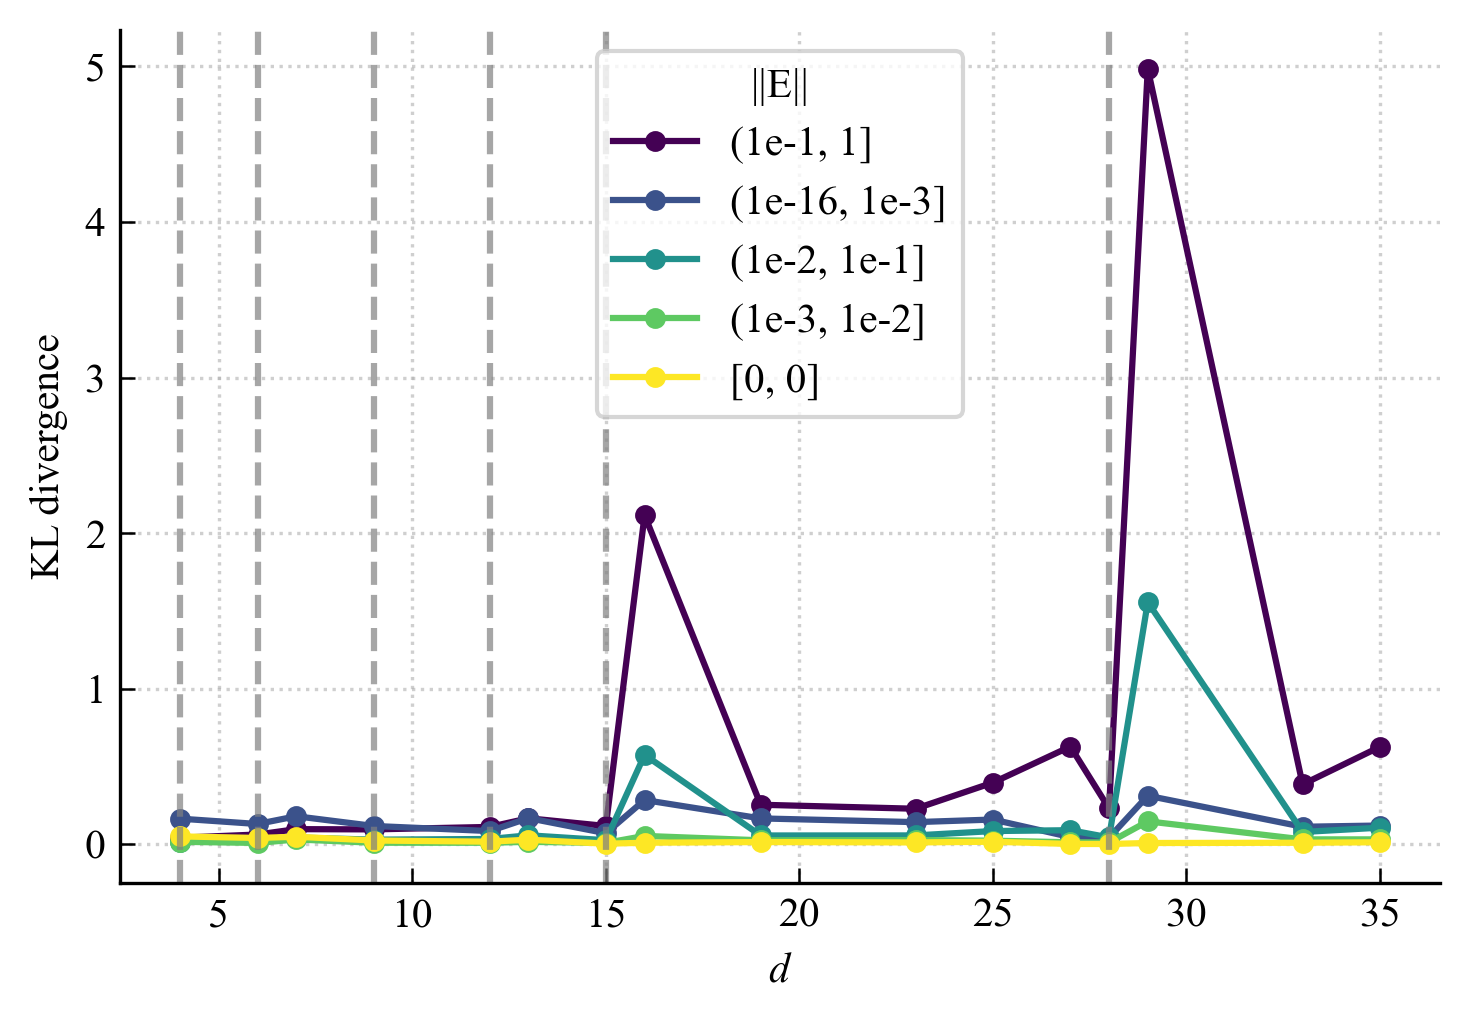

In [79]:
plot_avg_kl_vs_E(
    results,
    pretrained_dimensions=pretrained_dimensions
)

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def plot_avg_kl_vs_rad(
    results_dict,
    pretrained_dimensions=None
):
    """
    Plot average KL divergence vs dimension d for rad bins.
    """

    # Correct bin setup: N edges -> N-1 labels
    bin_edges = [0, 1e-8, 0.1, 0.4, 0.7, 1]
    bin_labels = [
        "[0, 1e-8]",
        "(1e-8, 0.1]",
        "(0.1, 0.4]",
        "(0.4, 0.7]",
        "(0.7, 1]",
    ]

    rows = []

    for d, df in results_dict.items():
        df = df.copy()

        df["rad_bin"] = pd.cut(
            df["rad"],
            bins=bin_edges,
            labels=bin_labels,
            include_lowest=True
        )

        grouped = df.groupby("rad_bin")["kl_loss"].mean()

        for bin_name, val in grouped.items():
            rows.append({
                "d": d,
                "rad_bin": bin_name,
                "avg_kl": val
            })

    plot_df = pd.DataFrame(rows)

    # Keep bins in desired order
    keep_bins = bin_labels
    plot_df = plot_df[plot_df["rad_bin"].isin(keep_bins)]

    # Pivot
    pivot = plot_df.pivot(index="d", columns="rad_bin", values="avg_kl")
    pivot = pivot.sort_index()

    # Ensure column order
    pivot = pivot[keep_bins]

    # Plot
    plt.figure()

    cmap = plt.cm.viridis
    colors = cmap(np.linspace(0, 1, len(pivot.columns)))

    for color, col in zip(colors, pivot.columns):
        plt.plot(pivot.index, pivot[col], marker='o', label=col, color=color)

    # Vertical lines for pretrained dimensions
    if pretrained_dimensions is not None:
        for d_val in pretrained_dimensions:
            plt.axvline(x=d_val, linestyle="--", color="grey", alpha=0.7)

    plt.xlabel("$d$")
    plt.ylabel("KL divergence")
    plt.legend(title="$\\rho(N)$", loc="upper left")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.yscale("log")

    plt.tight_layout()
    plt.savefig("latex/images/j8_a_loss.pdf")
    plt.show()

C:\Users\micha\AppData\Local\Temp\ipykernel_3996\1644105040.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("rad_bin")["kl_loss"].mean()
C:\Users\micha\AppData\Local\Temp\ipykernel_3996\1644105040.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("rad_bin")["kl_loss"].mean()
C:\Users\micha\AppData\Local\Temp\ipykernel_3996\1644105040.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence t

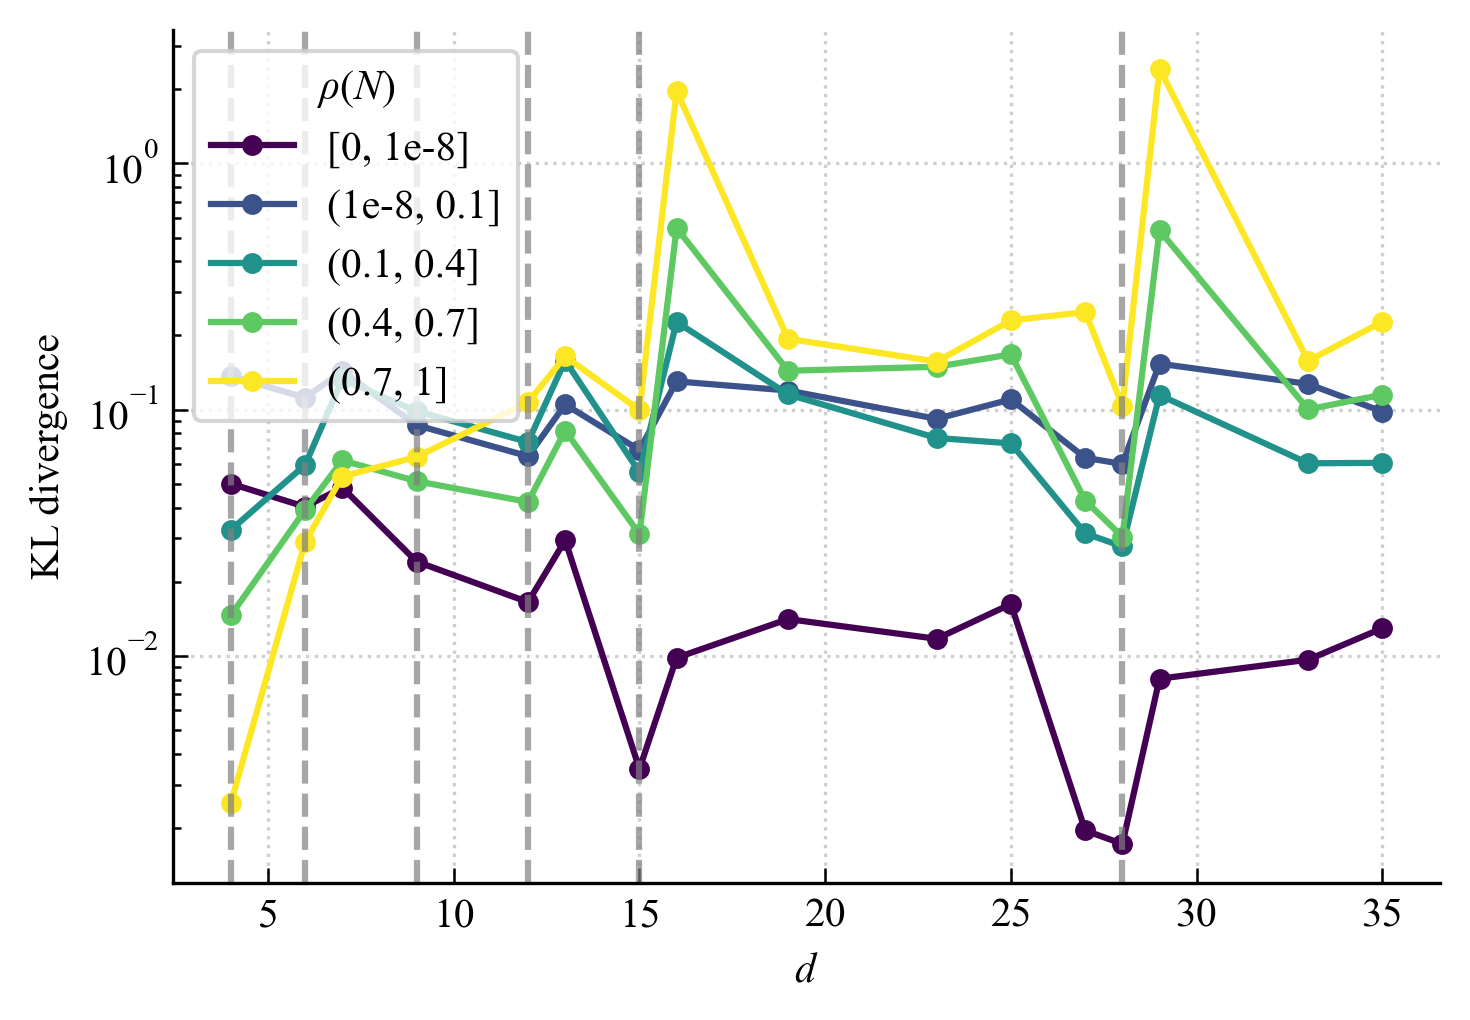

In [81]:
plot_avg_kl_vs_rad(
    results,
    pretrained_dimensions=pretrained_dimensions
)